In [1]:

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras
import h5py 

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
from keras import regularizers


from sklearn.model_selection import GridSearchCV
from keras.wrappers.scikit_learn import KerasClassifier
from keras.optimizers import Adam

print(tf.__version__)

Using TensorFlow backend.


2.2.0-rc3


Google SVHN Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
h5f= h5py.File('/content/drive/My Drive/Colab Notebooks/SVHN_single_grey1.h5','r')
list(h5f.keys())

['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']

In [4]:
X_train=h5f['X_train'][:]
y_train =h5f['y_train'][:]

X_test=h5f['X_test'][:]
y_test =h5f['y_test'][:]

X_val=h5f['X_val'][:]
y_val =h5f['y_val'][:]
h5f.close()

print('Training set', X_train.shape, y_train.shape)
print('Validation set', X_val.shape, y_val.shape)
print('Test set', X_test.shape, y_test.shape)





Training set (42000, 32, 32) (42000,)
Validation set (60000, 32, 32) (60000,)
Test set (18000, 32, 32) (18000,)


Check unique Labels

In [5]:
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


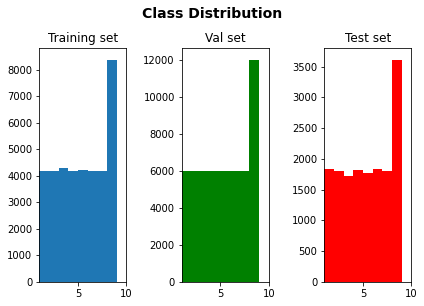

In [6]:
fig, (ax1, ax2,ax3) = plt.subplots(1, 3, sharex=True)

fig.suptitle('Class Distribution', fontsize=14, fontweight='bold', y=1.05)

ax1.hist(y_train, bins=9)
ax1.set_title("Training set")
ax1.set_xlim(1, 10)

ax2.hist(y_val, color='g', bins=9)
ax2.set_title("Val set")

ax3.hist(y_test, color='r', bins=9)
ax3.set_title("Test set")

fig.tight_layout()

The data set skewed towards 9 but otherwise looks like a balanced classification

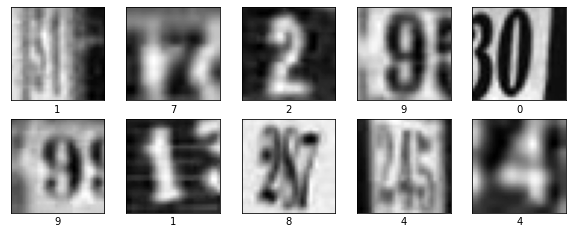

In [7]:

plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test[i], cmap=plt.cm.binary)
    plt.xlabel(y_test[i])
plt.show()

**ADAM OPTIMIZATION .**

In [0]:
X_train_google_cpy = X_train / 255
y_train_google_cpy = y_train

X_test_google_cpy = X_test / 255
y_test_google_cpy = y_test

X_val_google_cpy = X_val / 255
y_val_google_cpy = y_val

TRY WITH 
1. CHANGING NETWORK
2. ADDING BATCH NORMALIZATION BETWEEN EVERY STEP 


In [0]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation='relu'),
   # keras.layers.Dense(32, activation='relu'),
    #keras.layers.BatchNormalization(),
    keras.layers.Dense(10)
])

CHANGED THE NETWORK BUT ABOVE ONE WAS FOUND TO BE GOOD.

TRY WITH
BATCH SIZE  32,64,128

In [10]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
history = model.fit(X_train_google_cpy, y_train, epochs=45,batch_size= 32,validation_data=(X_val_google_cpy,y_val)
          )

Epoch 1/45
1313/1313 [==============================] - 7s 5ms/step - loss: 1.3949 - accuracy: 0.5454 - val_loss: 0.9658 - val_accuracy: 0.7059
Epoch 2/45
1313/1313 [==============================] - 7s 5ms/step - loss: 0.9785 - accuracy: 0.6901 - val_loss: 0.7984 - val_accuracy: 0.7557
Epoch 3/45
1313/1313 [==============================] - 7s 5ms/step - loss: 0.8576 - accuracy: 0.7300 - val_loss: 0.7031 - val_accuracy: 0.7870
Epoch 4/45
1313/1313 [==============================] - 7s 5ms/step - loss: 0.7862 - accuracy: 0.7531 - val_loss: 0.6358 - val_accuracy: 0.8117
Epoch 5/45
1313/1313 [==============================] - 7s 5ms/step - loss: 0.7343 - accuracy: 0.7704 - val_loss: 0.5943 - val_accuracy: 0.8238
Epoch 6/45
1313/1313 [==============================] - 7s 5ms/step - loss: 0.7013 - accuracy: 0.7806 - val_loss: 0.5925 - val_accuracy: 0.8211
Epoch 7/45
1313/1313 [==============================] - 7s 5ms/step - loss: 0.6707 - accuracy: 0.7870 - val_loss: 0.5609 - val_accuracy:

In [11]:
test_loss, test_acc = model.evaluate(X_test_google_cpy,  y_test, verbose=2)

print('\nTest accuracy with Adam batch size = 32:', test_acc)

563/563 - 1s - loss: 0.5230 - accuracy: 0.8545

Test accuracy with Adam batch size = 32: 0.8544999957084656


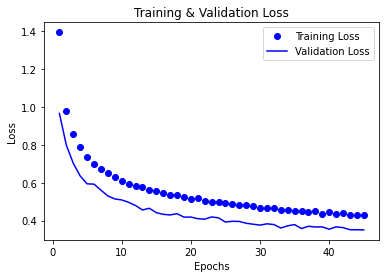

In [12]:
history_dict=history.history
history_dict.keys()
loss_values=history_dict['loss']
val_loss_values=history_dict['val_loss']
epochs= range(1,len(loss_values)+1)
plt.plot(epochs,loss_values,'bo',label='Training Loss')
plt.plot(epochs,val_loss_values,'b',label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [13]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation='relu'),
   # keras.layers.Dense(32, activation='relu'),
    #keras.layers.BatchNormalization(),
    keras.layers.Dense(10)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
history = model.fit(X_train_google_cpy, y_train, epochs=45,batch_size= 64,validation_data=(X_val_google_cpy,y_val)
          )

Epoch 1/45
657/657 [==============================] - 4s 6ms/step - loss: 1.3339 - accuracy: 0.5705 - val_loss: 0.9401 - val_accuracy: 0.7130
Epoch 2/45
657/657 [==============================] - 4s 6ms/step - loss: 0.9106 - accuracy: 0.7171 - val_loss: 0.8311 - val_accuracy: 0.7413
Epoch 3/45
657/657 [==============================] - 4s 6ms/step - loss: 0.7997 - accuracy: 0.7521 - val_loss: 0.6996 - val_accuracy: 0.7913
Epoch 4/45
657/657 [==============================] - 4s 6ms/step - loss: 0.7300 - accuracy: 0.7730 - val_loss: 0.6355 - val_accuracy: 0.8112
Epoch 5/45
657/657 [==============================] - 4s 6ms/step - loss: 0.6818 - accuracy: 0.7906 - val_loss: 0.5940 - val_accuracy: 0.8216
Epoch 6/45
657/657 [==============================] - 4s 6ms/step - loss: 0.6424 - accuracy: 0.8008 - val_loss: 0.5703 - val_accuracy: 0.8308
Epoch 7/45
657/657 [==============================] - 4s 6ms/step - loss: 0.6100 - accuracy: 0.8119 - val_loss: 0.5700 - val_accuracy: 0.8294
Epoch 

In [14]:
test_loss, test_acc = model.evaluate(X_test_google_cpy,  y_test, verbose=2)

print('\nTest accuracy with Adam batch size = 64:', test_acc)

563/563 - 1s - loss: 0.5552 - accuracy: 0.8566

Test accuracy with Adam batch size = 64: 0.8566111326217651


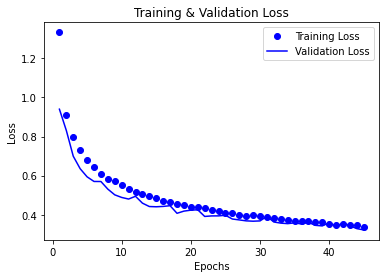

In [15]:
history_dict=history.history
history_dict.keys()
loss_values=history_dict['loss']
val_loss_values=history_dict['val_loss']
epochs= range(1,len(loss_values)+1)
plt.plot(epochs,loss_values,'bo',label='Training Loss')
plt.plot(epochs,val_loss_values,'b',label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation='relu'),
   # keras.layers.Dense(32, activation='relu'),
    #keras.layers.BatchNormalization(),
    keras.layers.Dense(10)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
history = model.fit(X_train_google_cpy, y_train, epochs=45,batch_size= 128,validation_data=(X_val_google_cpy,y_val)
          )

Epoch 1/45
329/329 [==============================] - 3s 9ms/step - loss: 1.3932 - accuracy: 0.5524 - val_loss: 1.0503 - val_accuracy: 0.6943
Epoch 2/45
329/329 [==============================] - 3s 9ms/step - loss: 0.9130 - accuracy: 0.7175 - val_loss: 0.8013 - val_accuracy: 0.7579
Epoch 3/45
329/329 [==============================] - 3s 9ms/step - loss: 0.7712 - accuracy: 0.7617 - val_loss: 0.6742 - val_accuracy: 0.7990
Epoch 4/45
329/329 [==============================] - 3s 9ms/step - loss: 0.6934 - accuracy: 0.7870 - val_loss: 0.6544 - val_accuracy: 0.7997
Epoch 5/45
329/329 [==============================] - 3s 9ms/step - loss: 0.6526 - accuracy: 0.7990 - val_loss: 0.6560 - val_accuracy: 0.8013
Epoch 6/45
329/329 [==============================] - 3s 9ms/step - loss: 0.6073 - accuracy: 0.8142 - val_loss: 0.5773 - val_accuracy: 0.8262
Epoch 7/45
329/329 [==============================] - 3s 9ms/step - loss: 0.5925 - accuracy: 0.8177 - val_loss: 0.5308 - val_accuracy: 0.8423
Epoch 

In [17]:
test_loss, test_acc = model.evaluate(X_test_google_cpy,  y_test, verbose=2)

print('\nTest accuracy with Adam batch size = 128:', test_acc)

563/563 - 1s - loss: 0.6284 - accuracy: 0.8421

Test accuracy with Adam batch size = 128: 0.8421111106872559


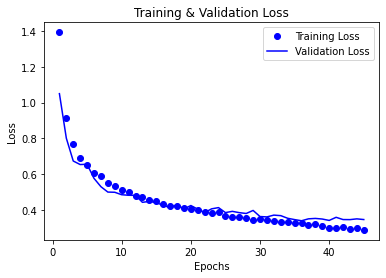

In [18]:
history_dict=history.history
history_dict.keys()
loss_values=history_dict['loss']
val_loss_values=history_dict['val_loss']
epochs= range(1,len(loss_values)+1)
plt.plot(epochs,loss_values,'bo',label='Training Loss')
plt.plot(epochs,val_loss_values,'b',label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

CONCLUSION: LOOKS LIKE BATCH SIZE OF 32  IS SLIGHTLY BETTER .


Test accuracy with Adam ,batch size = 32: 0.8553 loss: 0.5322 45 epch

Test accuracy with Adam, batch size = 64: 0.8497 loss 0.5708 45 epch

Test accuracy with Adam batch size = 128: 0.8455 loss: 0.6053 45 epch





**LET US INTRODUCE DROP OUT AND CHECK WHERE WE GO**

In [0]:
modelWithDropOut02 = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
  
    keras.layers.Dense(10)
])

In [20]:
modelWithDropOut02.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
history = modelWithDropOut02.fit(X_train_google_cpy, y_train, epochs=45,batch_size= 32,validation_data=(X_val_google_cpy,y_val)
          )

Epoch 1/45
1313/1313 [==============================] - 7s 5ms/step - loss: 1.4922 - accuracy: 0.5027 - val_loss: 0.9943 - val_accuracy: 0.6921
Epoch 2/45
1313/1313 [==============================] - 7s 5ms/step - loss: 1.0622 - accuracy: 0.6636 - val_loss: 0.8040 - val_accuracy: 0.7606
Epoch 3/45
1313/1313 [==============================] - 7s 5ms/step - loss: 0.9357 - accuracy: 0.7061 - val_loss: 0.7295 - val_accuracy: 0.7807
Epoch 4/45
1313/1313 [==============================] - 7s 5ms/step - loss: 0.8640 - accuracy: 0.7289 - val_loss: 0.6597 - val_accuracy: 0.8055
Epoch 5/45
1313/1313 [==============================] - 7s 5ms/step - loss: 0.8178 - accuracy: 0.7455 - val_loss: 0.6373 - val_accuracy: 0.8101
Epoch 6/45
1313/1313 [==============================] - 7s 5ms/step - loss: 0.7792 - accuracy: 0.7584 - val_loss: 0.6098 - val_accuracy: 0.8197
Epoch 7/45
1313/1313 [==============================] - 7s 5ms/step - loss: 0.7587 - accuracy: 0.7647 - val_loss: 0.5744 - val_accuracy:

In [21]:
test_loss, test_acc = modelWithDropOut02.evaluate(X_test_google_cpy,  y_test, verbose=2)

print('\nTest accuracy with Adam batch size = 32 AND DROPOUT 0.2:', test_acc)

563/563 - 1s - loss: 0.4929 - accuracy: 0.8601

Test accuracy with Adam batch size = 32 AND DROPOUT 0.2: 0.8600555658340454


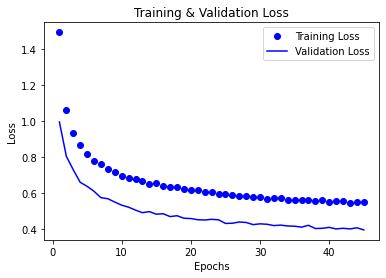

In [22]:
history_dict=history.history
history_dict.keys()
loss_values=history_dict['loss']
val_loss_values=history_dict['val_loss']
epochs= range(1,len(loss_values)+1)
plt.plot(epochs,loss_values,'bo',label='Training Loss')
plt.plot(epochs,val_loss_values,'b',label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [23]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(64, activation='relu'),
  
    keras.layers.Dense(10)
])
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
history = model.fit(X_train_google_cpy, y_train, epochs=45,batch_size= 32,validation_data=(X_val_google_cpy,y_val)
          )

Epoch 1/45
1313/1313 [==============================] - 7s 5ms/step - loss: 1.4476 - accuracy: 0.5179 - val_loss: 1.0201 - val_accuracy: 0.6818
Epoch 2/45
1313/1313 [==============================] - 11s 8ms/step - loss: 1.0262 - accuracy: 0.6745 - val_loss: 0.7863 - val_accuracy: 0.7655
Epoch 3/45
1313/1313 [==============================] - 7s 5ms/step - loss: 0.8968 - accuracy: 0.7176 - val_loss: 0.6994 - val_accuracy: 0.7918
Epoch 4/45
1313/1313 [==============================] - 7s 5ms/step - loss: 0.8277 - accuracy: 0.7387 - val_loss: 0.6336 - val_accuracy: 0.8163
Epoch 5/45
1313/1313 [==============================] - 7s 5ms/step - loss: 0.7727 - accuracy: 0.7595 - val_loss: 0.6194 - val_accuracy: 0.8153
Epoch 6/45
1313/1313 [==============================] - 7s 5ms/step - loss: 0.7440 - accuracy: 0.7686 - val_loss: 0.5824 - val_accuracy: 0.8286
Epoch 7/45
1313/1313 [==============================] - 7s 5ms/step - loss: 0.7138 - accuracy: 0.7772 - val_loss: 0.5726 - val_accuracy

In [24]:
test_loss, test_acc = model.evaluate(X_test_google_cpy,  y_test, verbose=2)

print('\nTest accuracy with Adam batch size = 32 ', test_acc)

563/563 - 1s - loss: 0.4956 - accuracy: 0.8625

Test accuracy with Adam batch size = 32  0.862500011920929




Test accuracy with Adam batch size = 32 AND DROPOUT 0.2: 0.8622221946716309 loss: 0.4902





Test accuracy with Adam batch size = 32 AND DROPOUT 0.1: 0.8586 loss: 0.5036

DROP OUT 0.2 is better as lower loss and better accuracy.



1.  Try bringing in Regularization




In [25]:
from keras import regularizers

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu',kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu',kernel_regularizer=regularizers.l2(0.001)),
  
    keras.layers.Dense(10)
])
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
history = model.fit(X_train_google_cpy, y_train, epochs=45,batch_size= 32,validation_data=(X_val_google_cpy,y_val)
          )

Epoch 1/45
1313/1313 [==============================] - 8s 6ms/step - loss: 1.7838 - accuracy: 0.5022 - val_loss: 1.3089 - val_accuracy: 0.6757
Epoch 2/45
1313/1313 [==============================] - 8s 6ms/step - loss: 1.3547 - accuracy: 0.6407 - val_loss: 1.1158 - val_accuracy: 0.7239
Epoch 3/45
1313/1313 [==============================] - 8s 6ms/step - loss: 1.2253 - accuracy: 0.6759 - val_loss: 1.0421 - val_accuracy: 0.7405
Epoch 4/45
1313/1313 [==============================] - 8s 6ms/step - loss: 1.1422 - accuracy: 0.6972 - val_loss: 0.9702 - val_accuracy: 0.7612
Epoch 5/45
1313/1313 [==============================] - 8s 6ms/step - loss: 1.0863 - accuracy: 0.7162 - val_loss: 0.9007 - val_accuracy: 0.7839
Epoch 6/45
1313/1313 [==============================] - 8s 6ms/step - loss: 1.0503 - accuracy: 0.7270 - val_loss: 0.8802 - val_accuracy: 0.7877
Epoch 7/45
1313/1313 [==============================] - 8s 6ms/step - loss: 1.0213 - accuracy: 0.7337 - val_loss: 0.8501 - val_accuracy:

In [26]:
test_loss, test_acc = model.evaluate(X_test_google_cpy,  y_test, verbose=2)

print('\nTest accuracy with Adam batch size = 32 with L2 Reg ', test_acc)

563/563 - 1s - loss: 0.7576 - accuracy: 0.8176

Test accuracy with Adam batch size = 32 with L2 Reg  0.8176110982894897


In [27]:
from keras import regularizers

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu',kernel_regularizer=regularizers.l1(0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu',kernel_regularizer=regularizers.l1(0.001)),
  
    keras.layers.Dense(10)
])
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
history = model.fit(X_train_google_cpy, y_train, epochs=45,batch_size= 32,validation_data=(X_val_google_cpy,y_val)
          )

Epoch 1/45
1313/1313 [==============================] - 8s 6ms/step - loss: 3.3464 - accuracy: 0.4480 - val_loss: 2.2653 - val_accuracy: 0.5735
Epoch 2/45
1313/1313 [==============================] - 8s 6ms/step - loss: 2.1253 - accuracy: 0.5720 - val_loss: 1.8489 - val_accuracy: 0.6427
Epoch 3/45
1313/1313 [==============================] - 8s 6ms/step - loss: 1.8317 - accuracy: 0.6089 - val_loss: 1.6039 - val_accuracy: 0.6743
Epoch 4/45
1313/1313 [==============================] - 8s 6ms/step - loss: 1.6678 - accuracy: 0.6320 - val_loss: 1.3923 - val_accuracy: 0.7229
Epoch 5/45
1313/1313 [==============================] - 8s 6ms/step - loss: 1.5650 - accuracy: 0.6491 - val_loss: 1.3574 - val_accuracy: 0.7187
Epoch 6/45
1313/1313 [==============================] - 8s 6ms/step - loss: 1.4806 - accuracy: 0.6648 - val_loss: 1.3478 - val_accuracy: 0.7088
Epoch 7/45
1313/1313 [==============================] - 8s 6ms/step - loss: 1.4232 - accuracy: 0.6786 - val_loss: 1.2375 - val_accuracy:

In [28]:
test_loss, test_acc = model.evaluate(X_test_google_cpy,  y_test, verbose=2)

print('\nTest accuracy with Adam batch size = 32 with L1 Reg ', test_acc)

563/563 - 1s - loss: 0.9227 - accuracy: 0.8177

Test accuracy with Adam batch size = 32 with L1 Reg  0.8177222013473511


L1 and L2 Regularization combined with Dropout did not help .We will use the model with modelWithDropOut02

In [0]:
X_train=X_train.reshape((42000, 32* 32))
X_train = X_train.astype('float32') / 255

X_test=X_test.reshape((18000, 32* 32))
X_test = X_test.astype('float32') / 255

X_val=X_val.reshape((60000, 32* 32))
X_val = X_val.astype('float32') / 255





> Indented block



In [0]:
from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test= to_categorical(y_test)
y_val= to_categorical(y_val)


RMSPROP Optimizer with Drop out and Regularizers

In [0]:
modelrmsProp = keras.Sequential([
  
    keras.layers.BatchNormalization(),
    keras.layers.Dense(512, activation='relu',kernel_regularizer=regularizers.l1(0.001)),
    keras.layers.Dropout(0.2),
   
    keras.layers.Dense(256, activation='relu',kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(128, activation='relu',kernel_regularizer=regularizers.l1(0.001)),
    #keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu',kernel_regularizer=regularizers.l2(0.001)),
    
    keras.layers.Dense(10,activation='softmax')
])

In [0]:
modelrmsProp.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])

In [33]:
history = modelrmsProp.fit(X_train, y_train, epochs=45,batch_size= 128,validation_data=(X_val,y_val)
          )

Epoch 1/45
329/329 [==============================] - 10s 31ms/step - loss: 4.9089 - accuracy: 0.2678 - val_loss: 2.7680 - val_accuracy: 0.3434
Epoch 2/45
329/329 [==============================] - 10s 31ms/step - loss: 2.3569 - accuracy: 0.4421 - val_loss: 2.2479 - val_accuracy: 0.4719
Epoch 3/45
329/329 [==============================] - 10s 31ms/step - loss: 2.1465 - accuracy: 0.5038 - val_loss: 2.2094 - val_accuracy: 0.4907
Epoch 4/45
329/329 [==============================] - 10s 31ms/step - loss: 2.0338 - accuracy: 0.5420 - val_loss: 2.0743 - val_accuracy: 0.5425
Epoch 5/45
329/329 [==============================] - 10s 31ms/step - loss: 1.9543 - accuracy: 0.5720 - val_loss: 1.9471 - val_accuracy: 0.5713
Epoch 6/45
329/329 [==============================] - 10s 31ms/step - loss: 1.8891 - accuracy: 0.5957 - val_loss: 1.8342 - val_accuracy: 0.6221
Epoch 7/45
329/329 [==============================] - 10s 31ms/step - loss: 1.8480 - accuracy: 0.6115 - val_loss: 1.9626 - val_accuracy:

In [34]:
test_loss, test_acc = modelrmsProp.evaluate(X_test,  y_test, verbose=2)

print('\nTest accuracy with rmsprop:', test_acc)

563/563 - 2s - loss: 1.5845 - accuracy: 0.6961

Test accuracy with rmsprop: 0.6961110830307007


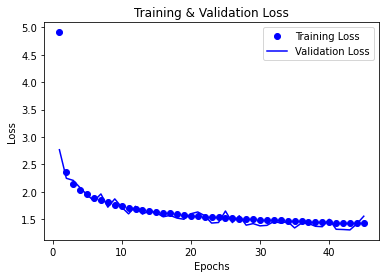

In [35]:
history_dict=history.history
history_dict.keys()
loss_values=history_dict['loss']
val_loss_values=history_dict['val_loss']
epochs= range(1,len(loss_values)+1)
plt.plot(epochs,loss_values,'bo',label='Training Loss')
plt.plot(epochs,val_loss_values,'b',label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

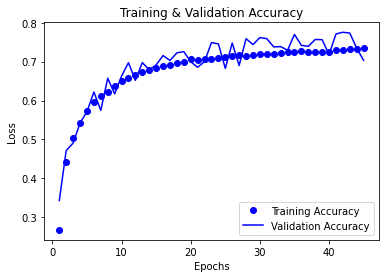

In [36]:
plt.clf()

acc=history_dict['accuracy']
val_acc=history_dict['val_accuracy']

plt.plot(epochs,acc,'bo',label='Training Accuracy')
plt.plot(epochs,val_acc,'b',label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [37]:
modelrmsPropNoReg = keras.Sequential([
  
    keras.layers.BatchNormalization(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.2),
   
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(128, activation='relu'),
    #keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    
    keras.layers.Dense(10,activation='softmax')
])
modelrmsPropNoReg.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])
history = modelrmsPropNoReg.fit(X_train, y_train, epochs=45,batch_size= 128,validation_data=(X_val,y_val)
          )

Epoch 1/45
329/329 [==============================] - 9s 29ms/step - loss: 1.7177 - accuracy: 0.4048 - val_loss: 1.2519 - val_accuracy: 0.6065
Epoch 2/45
329/329 [==============================] - 9s 29ms/step - loss: 1.1237 - accuracy: 0.6423 - val_loss: 1.0321 - val_accuracy: 0.6666
Epoch 3/45
329/329 [==============================] - 9s 28ms/step - loss: 0.9516 - accuracy: 0.7027 - val_loss: 0.9705 - val_accuracy: 0.6951
Epoch 4/45
329/329 [==============================] - 9s 28ms/step - loss: 0.8639 - accuracy: 0.7305 - val_loss: 0.8151 - val_accuracy: 0.7396
Epoch 5/45
329/329 [==============================] - 9s 27ms/step - loss: 0.7891 - accuracy: 0.7552 - val_loss: 0.7868 - val_accuracy: 0.7511
Epoch 6/45
329/329 [==============================] - 9s 28ms/step - loss: 0.7355 - accuracy: 0.7744 - val_loss: 0.7784 - val_accuracy: 0.7718
Epoch 7/45
329/329 [==============================] - 9s 27ms/step - loss: 0.6991 - accuracy: 0.7840 - val_loss: 0.7529 - val_accuracy: 0.7681

In [38]:
test_loss, test_acc = modelrmsPropNoReg.evaluate(X_test,  y_test, verbose=2)

print('\nTest accuracy with rmsprop with no regularizations:', test_acc)

563/563 - 1s - loss: 0.5871 - accuracy: 0.8499

Test accuracy with rmsprop with no regularizations: 0.8498888611793518


SGD Optimizers with drop outs

In [39]:
modelSgdPropNoReg = keras.Sequential([
  
    keras.layers.BatchNormalization(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.2),
   
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(128, activation='relu'),
    #keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    
    keras.layers.Dense(10,activation='softmax')
])
modelSgdPropNoReg.compile(optimizer='SGD',loss='categorical_crossentropy',metrics=['accuracy'])
history = modelSgdPropNoReg.fit(X_train, y_train, epochs=45,batch_size= 128,validation_data=(X_val,y_val)
          )


Epoch 1/45
329/329 [==============================] - 8s 26ms/step - loss: 2.2975 - accuracy: 0.1335 - val_loss: 2.2358 - val_accuracy: 0.2139
Epoch 2/45
329/329 [==============================] - 8s 25ms/step - loss: 2.1552 - accuracy: 0.2313 - val_loss: 1.9633 - val_accuracy: 0.3537
Epoch 3/45
329/329 [==============================] - 8s 25ms/step - loss: 1.8374 - accuracy: 0.3870 - val_loss: 1.5398 - val_accuracy: 0.5229
Epoch 4/45
329/329 [==============================] - 8s 25ms/step - loss: 1.5028 - accuracy: 0.5119 - val_loss: 1.2610 - val_accuracy: 0.6145
Epoch 5/45
329/329 [==============================] - 8s 25ms/step - loss: 1.2919 - accuracy: 0.5888 - val_loss: 1.0854 - val_accuracy: 0.6757
Epoch 6/45
329/329 [==============================] - 8s 25ms/step - loss: 1.1566 - accuracy: 0.6345 - val_loss: 0.9870 - val_accuracy: 0.7035
Epoch 7/45
329/329 [==============================] - 8s 25ms/step - loss: 1.0745 - accuracy: 0.6661 - val_loss: 0.9481 - val_accuracy: 0.7082

In [40]:
test_loss, test_acc = modelSgdPropNoReg.evaluate(X_test,  y_test, verbose=2)

print('\nTest accuracy with SGD:', test_acc)

563/563 - 1s - loss: 0.5948 - accuracy: 0.8306

Test accuracy with SGD: 0.8305555582046509


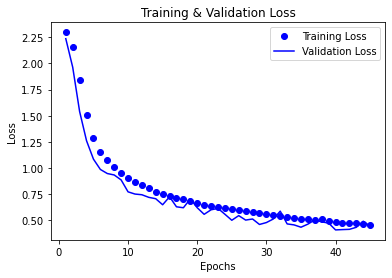

In [41]:
history_dict=history.history
history_dict.keys()
loss_values=history_dict['loss']
val_loss_values=history_dict['val_loss']
epochs= range(1,len(loss_values)+1)
plt.plot(epochs,loss_values,'bo',label='Training Loss')
plt.plot(epochs,val_loss_values,'b',label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

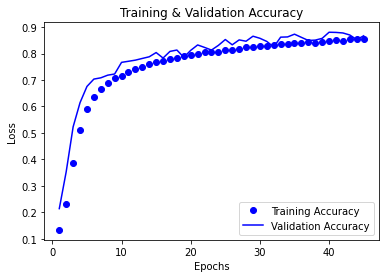

In [42]:
plt.clf()

acc=history_dict['accuracy']
val_acc=history_dict['val_accuracy']

plt.plot(epochs,acc,'bo',label='Training Accuracy')
plt.plot(epochs,val_acc,'b',label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

FINAL CONCLUSIONS

modelWithDropOut02 has better accuracy and lesser loss 

In [0]:
predictions = modelWithDropOut02.predict(X_test_google_cpy)


In [44]:
predictions[0]

array([-0.02607593,  1.1577005 , -2.8921347 , -1.4944612 , -2.2356024 ,
       -0.61523783, -1.1708615 , -0.63743687, -1.4346218 , -0.31410658],
      dtype=float32)

In [45]:
np.argmax(predictions[0])

1

In [47]:
y_test_google_cpy[0]


1

In [0]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

In [0]:
class_names = ['0', '1', '2', '3', '4',
               '5', '6', '7', '8', '9']

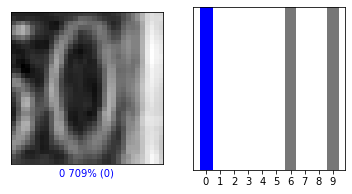

In [60]:
i = 20
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], y_test_google_cpy, X_test_google_cpy)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  y_test_google_cpy)
plt.show()

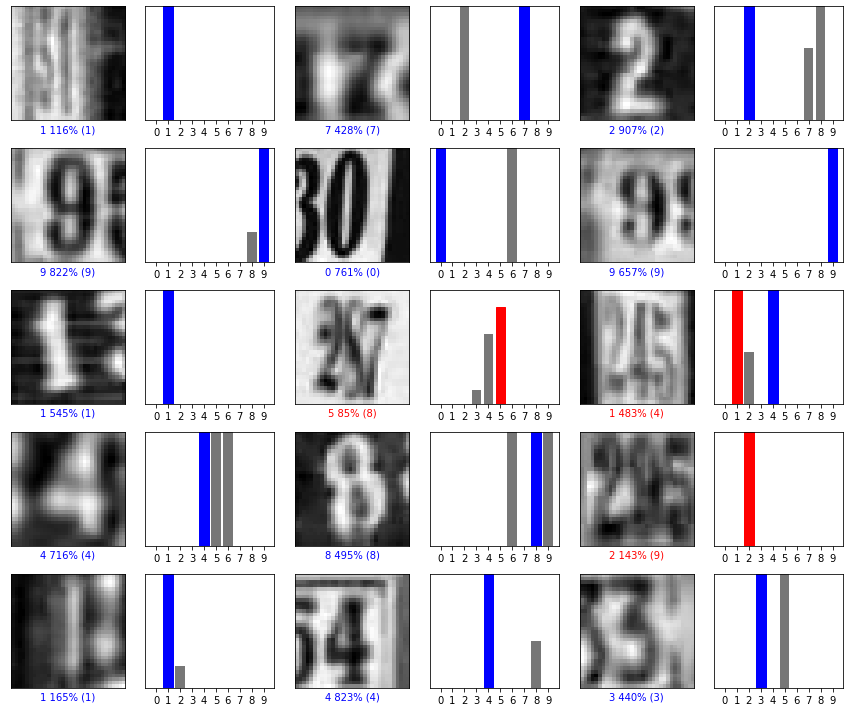

In [63]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], y_test_google_cpy, X_test_google_cpy)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], y_test_google_cpy)
plt.tight_layout()
plt.show()